# Final report — theory parameter sweeps (2026-08-12)

Bare-bones QDHT sweeps showing how each optic parameter shapes the on-axis
intensity $I(0, z)$, for whoever maintains this system next. Two families:

1. **Single axicon** (1" optic): axicon angle, input beam diameter
2. **Three-axicon telescope**: $L_{12}$ spacing (at fixed $\alpha_{1,2}$),
   axicon 1/2 angle, axicon 3 angle, input beam diameter

All sweeps hold the other parameters at the candidate-#1 baseline
($D$ = 4.59 mm, $\\alpha_{1,2}$ = 5°, $\\alpha_3$ = 0.5°,
$L_{12}$ = 190 mm, $L_{23}$ = 50 mm; $\\lambda$ = 650 nm, n = 1.4585).
Model: the webapp simulator (`simulate_recorded_optic` for the three-axicon
setup — the same entry point as the measurement notebooks — and the same
QDHT primitives for the single axicon). Curves are normalized to their own
peak; the quoted numbers (geometric $z_{max}$, $k_r$) come from the same
small-angle relations used in the report text.

In [486]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

REPO = Path.cwd().parent
for _name in ("bessel_beam_webapp",):
    if (REPO.parent / _name).exists():
        sys.path.insert(0, str(REPO.parent / _name))
        break

from simulator.qdht_axicon import (QDHT, axicon_kr, propagate_spectrum,
                                   simulate_recorded_optic, mm)

NOTEBOOK_STEM = "final_report_theory_2026_08_12"
IMAGES_DIR = Path("images") / NOTEBOOK_STEM
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

LAMDA_m = 650e-9
K0 = 2 * np.pi / LAMDA_m
N_UV_FUSED_SILICA = 1.4585
CANDIDATE_1 = dict(GaussianBeamWaist_mm=4.59, Axicon1_deg=5.0, Axicon2_deg=5.0,
            Axicon3_deg=0.5, L12_mm=190.0, L23_mm=50.0)

def save_fig(description):
    path = IMAGES_DIR / f"{description}.png"
    plt.savefig(path, dpi=800, bbox_inches="tight")
    print(f"saved {path}")


def deflect(alpha_deg):
    """Exact-Snell deflection angle (rad) for a thin axicon."""
    a = np.deg2rad(alpha_deg)
    return np.arcsin(np.clip(N_UV_FUSED_SILICA * np.sin(a), -1, 1)) - a


def sweep_colors(n):
    return [plt.get_cmap("inferno")(x) for x in np.linspace(0.05, 0.8, n)]


## Single axicon (1" optic)

A Gaussian beam through one axicon makes a Bessel-Gauss beam directly. The
two knobs: the axicon angle sets the cone angle $\\theta = (n-1)\\alpha$,
hence the core size ($k_r = k\\,\\theta$, first zero at $2.405/k_r$); the
input diameter sets how long the cones keep overlapping, i.e. the zone
length $z_{max} \\approx (D/2)/\\theta$. Sharper axicon = smaller core but
shorter zone; bigger beam = longer zone at the same core size.

In [487]:
# --- single axicon: on-axis I(0,z) machinery ---------------------------------
def single_axicon_onax(D_mm, alpha_deg, z_max_m, Nz=400, N=4096):
    w0 = D_mm * mm / 2
    kr = axicon_kr(alpha_deg, n=N_UV_FUSED_SILICA, k=K0)
    q = QDHT(N, 3.0 * w0)                    # domain: pad around the beam
    y0 = q.forward(np.exp(-(q.r / w0) ** 2) * np.exp(-1j * kr * q.r))
    z = np.linspace(1e-4, z_max_m, Nz)
    return z, q.onax(propagate_spectrum(y0, q.kr, K0, z)), kr


saved images/final_report_theory_2026_08_12/axicon_angle_sweep_D=4_59mm.png


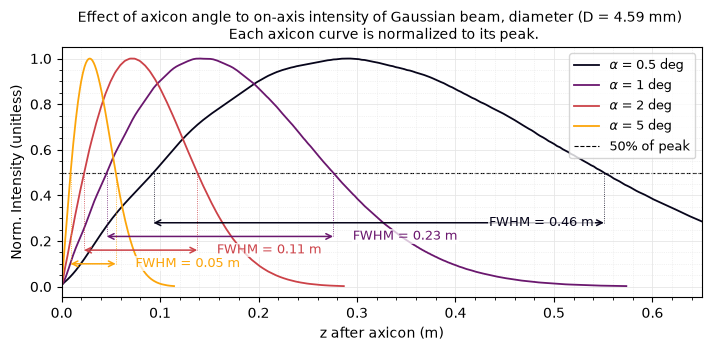

In [488]:
# --- sweep 1: axicon angle (single axicon) -----------------------------------
ANGLES_1AX = (0.5, 1.0, 2.0, 5.0)
D_FIX = CANDIDATE_1["GaussianBeamWaist_mm"]
D_FIX_STR = f"{D_FIX:g}".replace(".", "_")  # for filenames

def fwhm_span(z, I):
    """(lo, hi, width) where the curve crosses half its peak."""
    In = I / I.max()
    i = int(np.argmax(In))
    lo_i = np.where(In[:i] < 0.5)[0]          # last sample below half, rising
    hi_i = np.where(In[i:] < 0.5)[0]          # first sample below half, falling
    lo = (np.interp(0.5, [In[lo_i[-1]], In[lo_i[-1] + 1]],
                    [z[lo_i[-1]], z[lo_i[-1] + 1]]) if len(lo_i) else z[0])
    if len(hi_i):
        j = i + hi_i[0]
        hi = np.interp(0.5, [In[j], In[j - 1]], [z[j], z[j - 1]])
    else:
        hi = z[-1]
    return lo, hi, hi - lo


# FWHM dimension arrows: one per curve, staggered in height so the (heavily
# overlapping) spans stay readable; dotted extension lines tie each arrow end
# back to its actual 50% crossing on the curve.
# ARROW_Y = (0.44, 0.36, 0.28, 0.20, 0.12)
ARROW_Y = (0.28, 0.22, 0.16, 0.10, 0.04)  # more compact for the final report

X_MAX = 0.65                       # axis limit, also used for label placement

# transverse core-size factors (dimensionless J0 landmarks):
#   first null of J0 at 2.40483  -> core diameter  d0 = 2 x 2.40483 / k_r
#   J0^2 = 1/2      at 1.12636  -> core FWHM      dF = 2 x 1.12636 / k_r
J0_D = 2 * 2.40483
J0_FWHM = 2 * 1.12636

fig, ax = plt.subplots(figsize=(7, 3.4), layout="constrained")
for a_deg, c, y_arr in zip(ANGLES_1AX, sweep_colors(len(ANGLES_1AX)), ARROW_Y):
    th = deflect(a_deg)
    z_geo = (D_FIX * mm / 2) / th
    z, I, kr = single_axicon_onax(D_FIX, a_deg, 2 * z_geo)
    # transverse core size from k_r: first-null diameter and FWHM of J0^2
    d0_um = J0_D / kr * 1e6
    fw_um = J0_FWHM / kr * 1e6
    ax.plot(z, I / I.max(), color=c, lw=1.3,
            label=(f"$\\alpha$ = {a_deg:g} $\\deg$"))
    lo, hi, w = fwhm_span(z, I)
    ax.annotate("", xy=(lo, y_arr), xytext=(hi, y_arr),
                arrowprops=dict(arrowstyle="<->", color=c, lw=1.1,
                                shrinkA=0, shrinkB=0), zorder=4)
    for x_ in (lo, hi):
        ax.plot([x_, x_], [y_arr, 0.5], color=c, lw=0.6, ls=":", zorder=2)
    # label just past the right arrowhead — the spans are nested, so a
    # centered label would sit on top of the neighbouring arrows
    # label past the right arrowhead; if that would overflow the axis, tuck it
    # just inside the arrow instead (keeps every label within the frame)
    x_lab, ha_lab = hi + 0.02, "left"
    if hi + 0.22 * X_MAX > X_MAX:
        x_lab, ha_lab = hi - 0.01, "right"
    ax.text(x_lab, y_arr, f"FWHM = {w:.2f} m", color=c, fontsize=9,
            antialiased=True,
            ha=ha_lab, va="center", zorder=5,
            bbox=dict(fc="white", ec="none", alpha=0.75, pad=0.8,
                      ))

z_range = np.linspace(0, 1.4, 100)
ax.plot(z_range, [0.5 for _ in z_range], color="black", ls="--", lw=0.8, label="50% of peak", zorder=1)
ax.set_xlabel("z after axicon (m)")
ax.set_ylabel("Norm. Intensity (unitless)")
ax.set_xlim(0, X_MAX)
ax.minorticks_on()
ax.legend(fontsize=9, loc="upper right")
ax.set_title(f"Effect of axicon angle to on-axis intensity of Gaussian beam, diameter (D = {D_FIX:g} mm) \n Each axicon curve is normalized to its peak.", fontsize=10)
ax.grid(which="major", color="0.9", lw=0.6, ls="-")
ax.grid(which="minor", color="0.9", lw=0.5, ls=":")
save_fig(f"axicon_angle_sweep_D={D_FIX_STR}mm")
plt.show()


saved images/final_report_theory_2026_08_12/axicon_angle_sweep_gain_D=4_59mm.png


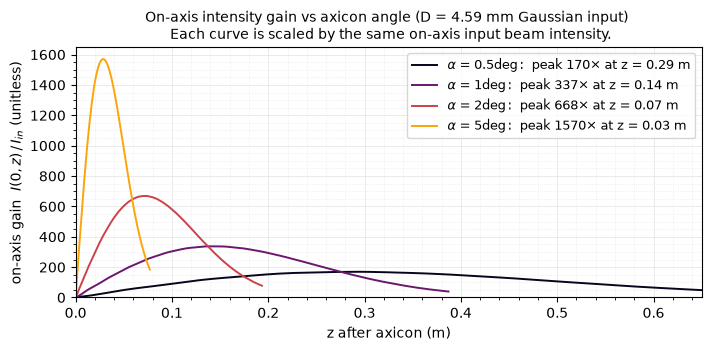

peak gain x axial FWHM (m): 0.5° -> 77.6, 1° -> 77.5, 2° -> 76.8, 5° -> 71.9


In [489]:
# --- sweep 1b: angle sweep on an ABSOLUTE on-axis intensity axis -------------
# Companion to the normalized figure above: instead of scaling every curve to
# its own peak, plot the on-axis intensity GAIN I(0,z)/I_in, i.e. relative to
# the input beam's on-axis intensity. Now the curves keep their true relative
# heights — a sharper axicon funnels the same power onto the axis harder, but
# over a proportionally shorter range. FWHM arrows sit at each curve's OWN
# half-max level (that is physically where the crossings are), so no vertical
# stagger is needed and the arrow ends land exactly on the curves.
def single_axicon_gain(D_mm, alpha_deg, z_max_m, Nz=400, N=4096):
    """I(0,z) / I_in for one axicon.

    I_in is the input on-axis intensity from the SAME r=0 extrapolation the
    propagated values use, so that estimator's small bias cancels in the ratio.
    """
    w0 = D_mm * mm / 2
    kr = axicon_kr(alpha_deg, n=N_UV_FUSED_SILICA, k=K0)
    q = QDHT(N, 3.0 * w0)
    y0 = q.forward(np.exp(-(q.r / w0) ** 2) * np.exp(-1j * kr * q.r))
    I_in = q.onax(np.atleast_2d(y0))[0]
    z = np.linspace(1e-4, z_max_m, Nz)
    return z, q.onax(propagate_spectrum(y0, q.kr, K0, z)) / I_in, kr


fig, ax = plt.subplots(figsize=(7, 3.4), layout="constrained")
gain_fwhm = []
for a_deg, c in zip(ANGLES_1AX, sweep_colors(len(ANGLES_1AX))):
    z_geo = (D_FIX * mm / 2) / deflect(a_deg)
    z, G, kr = single_axicon_gain(D_FIX, a_deg, 1.35 * z_geo)
    lo, hi, w = fwhm_span(z, G)
    g_pk = G.max()
    gain_fwhm.append(g_pk * w)
    ax.plot(z, G, color=c, lw=1.4,
            label=(f"$\\alpha$ = {a_deg:g}$\\deg$:  peak {g_pk:.0f}× at "
                   f"z = {z[int(np.argmax(G))]:.2f} m"))
    # FWHM dimension arrow at this curve's own half-max height
    # ax.annotate("", xy=(lo, 0.5 * g_pk), xytext=(hi, 0.5 * g_pk),
    #             arrowprops=dict(arrowstyle="<->", color=c, lw=1.0,
    #                             shrinkA=0, shrinkB=0), zorder=4)
    # x_lab, ha_lab = hi + 0.012, "left"      # tuck inside if it would overflow
    # if hi + 0.22 * X_MAX > X_MAX:
    #     x_lab, ha_lab = hi - 0.012, "right"
    # ax.text(x_lab, 0.5 * g_pk, f"FWHM = {w:.2f} m", color=c, fontsize=8,
    #         ha=ha_lab, va="center", zorder=5,
    #         bbox=dict(fc="white", ec="none", alpha=0.75, pad=0.6))
ax.set_xlabel("z after axicon (m)")
ax.set_ylabel("on-axis gain  $I(0,z)\\,/\\,I_{in}$ (unitless)")
ax.set_xlim(0, X_MAX)
ax.set_ylim(0, None)
ax.minorticks_on()
ax.legend(fontsize=9, loc="upper right")
ax.grid(which="major", color="0.9", lw=0.6, ls="-")
ax.grid(which="minor", color="0.9", lw=0.5, ls=":")
ax.set_title(f"On-axis intensity gain vs axicon angle (D = {D_FIX:g} mm "
             "Gaussian input) \n Each curve is scaled by the same on-axis input beam intensity.", fontsize=10)
save_fig(f"axicon_angle_sweep_gain_D={D_FIX_STR}mm")
plt.show()

# the trade-off is exact: concentrating harder costs range, one for one
print("peak gain x axial FWHM (m):",
      ", ".join(f"{a:g}° -> {v:.1f}" for a, v in zip(ANGLES_1AX, gain_fwhm)))

saved images/final_report_theory_2026_08_12/theory_single_axicon_angle_core.png


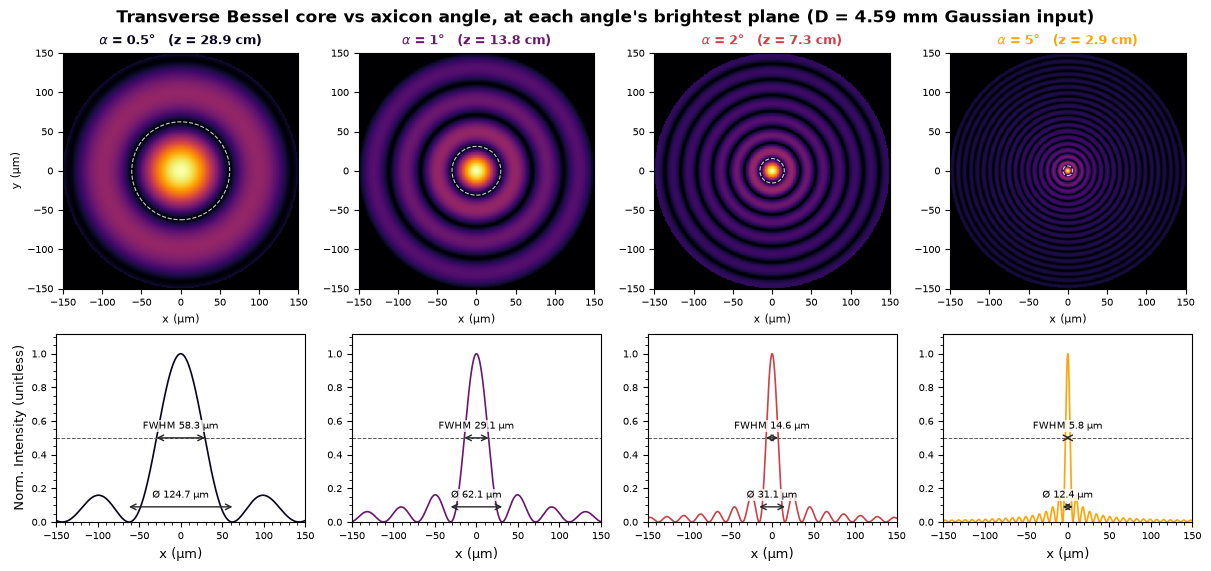

In [490]:
# --- angle sweep, transverse view: XY slice at the on-axis peak --------------
# Companion to the axial sweep above: for each angle, propagate to
# Z_SLICE_RULE = argmax I(0,z) (the brightest plane of that angle's Bessel
# zone) and show what a camera would see there, with the core diameter
# (first null) and FWHM measured off the radial cut.
# R_VIEW_UM sets a COMMON +-r window for every column (images and profiles
# alike), so the 1/alpha shrink of the core is visible directly across the
# row. Set it to None for per-column scaling (+-2.6 core radii), which makes
# the shape comparable instead but hides the size difference.
def single_axicon_field(D_mm, alpha_deg, N=4096):
    """Input-plane spectrum + grid for one axicon (same model as the on-axis cell)."""
    w0 = D_mm * mm / 2
    kr = axicon_kr(alpha_deg, n=N_UV_FUSED_SILICA, k=K0)
    q = QDHT(N, 3.0 * w0)
    y0 = q.forward(np.exp(-(q.r / w0) ** 2) * np.exp(-1j * kr * q.r))
    return q, y0, kr


def radial_slice(q, y0, z_m, r_max_m, Nr=600):
    """I(r) in one transverse plane."""
    r = np.linspace(0, r_max_m, Nr)
    E = propagate_spectrum(y0, q.kr, K0, z_m) @ q.eval_matrix(r)
    return r, np.abs(E) ** 2


def core_metrics(r, I):
    """(half-max radius, first-null radius) measured off the profile."""
    In = I / I[0]
    j = int(np.argmax(In < 0.5))
    r_half = np.interp(0.5, [In[j], In[j - 1]], [r[j], r[j - 1]])
    d = np.diff(In[j:])                       # first local minimum past half-max
    loc = np.where((d[:-1] < 0) & (d[1:] >= 0))[0]
    r_null = r[j + loc[0] + 1] if len(loc) else np.nan
    return r_half, r_null


R_VIEW_UM = 150.0            # common half-window (µm); None = per-column

fig, axes = plt.subplots(2, len(ANGLES_1AX), figsize=(3.0 * len(ANGLES_1AX), 5.6),
                         height_ratios=[1.25, 1.0], layout="constrained")
for col, (a_deg, c) in enumerate(zip(ANGLES_1AX, sweep_colors(len(ANGLES_1AX)))):
    ax_im, ax_pr = axes[0, col], axes[1, col]
    z_geo = (D_FIX * mm / 2) / deflect(a_deg)
    z, I_ax, kr = single_axicon_onax(D_FIX, a_deg, 1.35 * z_geo)
    z_pk = z[int(np.argmax(I_ax))]            # Z_SLICE_RULE: brightest plane
    q, y0, kr = single_axicon_field(D_FIX, a_deg)
    r_view = (R_VIEW_UM * 1e-6 if R_VIEW_UM is not None
              else 2.6 * J0_D / 2 / kr)       # common window, or 2.6 x core
    # sample finely enough for the ring pattern of the SMALLEST core in view
    n_rings = max(4, int(2 * r_view * kr / np.pi))
    r, Ir = radial_slice(q, y0, z_pk, r_view, Nr=max(600, 40 * n_rings))
    r_half, r_null = core_metrics(r, Ir)
    In = Ir / Ir[0]

    # --- XY slice (radially symmetric -> interpolate the profile onto a grid)
    ax_g = np.linspace(-r_view, r_view, max(320, 12 * n_rings))
    XX, YY = np.meshgrid(ax_g, ax_g)
    img = np.interp(np.hypot(XX, YY), r, In, right=0.0)
    ax_im.imshow(np.sqrt(img), cmap="inferno", vmin=0, vmax=1,
                 origin="lower", interpolation="nearest",
                 extent=[-r_view * 1e6, r_view * 1e6] * 2)
    ax_im.add_patch(plt.Circle((0, 0), r_null * 1e6, fill=False, color="w",
                               ls="--", lw=0.8, alpha=0.8))
    ax_im.set_title(f"$\\alpha$ = {a_deg:g}°   (z = {z_pk * 100:.1f} cm)",
                    fontsize=9, color=c, fontweight="bold")
    ax_im.set_xlabel("x (µm)", fontsize=8)
    ax_im.tick_params(labelsize=7)
    ax_im.set_box_aspect(1)
    if col == 0:
        ax_im.set_ylabel("y (µm)", fontsize=8)

    # --- radial cut with core-size dimension arrows
    ax_pr.plot(np.r_[-r[::-1], r] * 1e6, np.r_[In[::-1], In], color=c, lw=1.2)
    ax_pr.axhline(0.5, color="0.35", ls="--", lw=0.7)
    for y_a, rad, lab in ((0.5, r_half, f"FWHM {2 * r_half * 1e6:.1f} µm"),
                          (0.09, r_null, f"Ø {2 * r_null * 1e6:.1f} µm")):
        ax_pr.annotate("", xy=(-rad * 1e6, y_a), xytext=(rad * 1e6, y_a),
                       arrowprops=dict(arrowstyle="<->", color="0.15", lw=1.0,
                                       shrinkA=0, shrinkB=0), zorder=4)
        ax_pr.text(0, y_a + 0.04, lab, fontsize=7.5, ha="center", va="bottom",
                   zorder=5, bbox=dict(fc="white", ec="none", alpha=0.8, pad=0.5))
    ax_pr.set_xlim(-r_view * 1e6, r_view * 1e6)

    ax_pr.set_ylim(0, 1.12)
    ax_pr.set_xlabel("x (µm)", fontsize=9)
    ax_pr.tick_params(labelsize=7)
    ax_pr.minorticks_on()
    if col == 0:
        ax_pr.set_ylabel("Norm. Intensity (unitless)", fontsize=9)
fig.suptitle("Transverse Bessel core vs axicon angle, at each angle's brightest plane"
             + f" (D = {D_FIX:g} mm Gaussian input)",
             fontsize=12, fontweight="bold")
save_fig("theory_single_axicon_angle_core")
plt.show()

saved images/final_report_theory_2026_08_12/theory_single_axicon_diameter.png


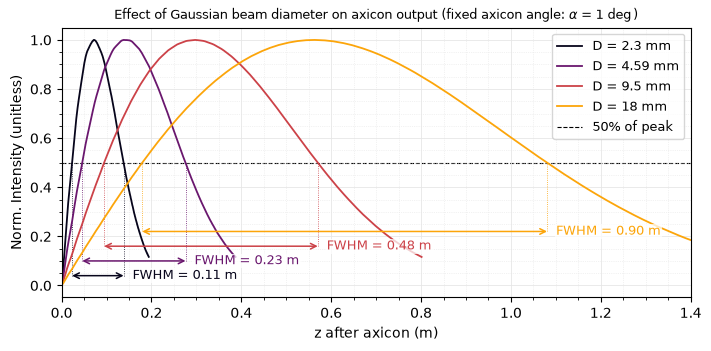

In [491]:
# --- sweep 2: input beam diameter (single axicon) ----------------------------
DIAMS_1AX = (2.3, 4.59, 9.5, 18.0)      # mm; 4.59/9.5 = the two bench beams
A_FIX = 1.0                             # deg, the axicon-3 angle
X_MAX = 1.4                       # axis limit, also used for label placement

# FWHM dimension arrows: one per curve, staggered in height so the (heavily
# overlapping) spans stay readable; dotted extension lines tie each arrow end
# back to its actual 50% crossing on the curve.
ARROW_Y = (0.28, 0.22, 0.16, 0.10, 0.04)  # more compact for the final report

fig, ax = plt.subplots(figsize=(7, 3.4), layout="constrained")
for D_mm, c, y_arr in zip(DIAMS_1AX, sweep_colors(len(DIAMS_1AX)), reversed(ARROW_Y)):
    th = deflect(A_FIX)
    z_geo = (D_mm * mm / 2) / th
    z, I, kr = single_axicon_onax(D_mm, A_FIX, 1.35 * z_geo)
    ax.plot(z, I / I.max(), color=c, lw=1.3,
            label=f"D = {D_mm:g} mm")
    lo, hi, w = fwhm_span(z, I)
    ax.annotate("", xy=(lo, y_arr), xytext=(hi, y_arr),
                arrowprops=dict(arrowstyle="<->", color=c, lw=1.1,
                                shrinkA=0, shrinkB=0), zorder=4)
    for x_ in (lo, hi):
        ax.plot([x_, x_], [y_arr, 0.5], color=c, lw=0.6, ls=":", zorder=2)
    # label just past the right arrowhead — the spans are nested, so a
    # centered label would sit on top of the neighbouring arrows
    # label past the right arrowhead; if that would overflow the axis, tuck it
    # just inside the arrow instead (keeps every label within the frame)
    x_lab, ha_lab = hi + 0.02, "left"
    if hi + 0.22 * X_MAX > X_MAX:
        x_lab, ha_lab = hi - 0.01, "right"
    ax.text(x_lab, y_arr, f"FWHM = {w:.2f} m", color=c, fontsize=9,
            antialiased=True,
            ha=ha_lab, va="center", zorder=5,
            bbox=dict(fc="white", ec="none", alpha=0.75, pad=0.8,
                      ))

z_range = np.linspace(0, X_MAX, 100)
ax.plot(z_range, [0.5 for _ in z_range], color="black", ls="--", lw=0.8, label="50% of peak", zorder=1)
ax.set_xlabel("z after axicon (m)")
ax.set_ylabel("Norm. Intensity (unitless)")
ax.set_xlim(0, X_MAX)
ax.minorticks_on()
ax.legend(fontsize=9, loc="upper right")
ax.set_title(f"Effect of Gaussian beam diameter on axicon output (fixed axicon angle: $\\alpha$ = {A_FIX:g} $\\deg$)", fontsize=9)
ax.grid(which="major", color="0.9", lw=0.6, ls="-")
ax.grid(which="minor", color="0.9", lw=0.5, ls=":")
save_fig("theory_single_axicon_diameter")
plt.show()


## Three-axicon "telescope"

In [492]:
# --- three-axicon sweep machinery --------------------------------------------
def ring_radius_mm(optic):
    return deflect(optic["Axicon1_deg"]) * optic["L12_mm"]


def sweep_three_axicon(param, values, ax, fmt, note=""):
    for v, c in zip(values, sweep_colors(len(values))):
        optic = dict(CANDIDATE_1)
        if param == "a12":
            optic["Axicon1_deg"] = optic["Axicon2_deg"] = v
        elif param == "a3":
            optic["Axicon3_deg"] = v
        elif param == "D":
            optic["GaussianBeamWaist_mm"] = v
        elif param == "L12":
            optic["L12_mm"] = v
        try:
            _, model = simulate_recorded_optic(optic, N=4096, Nz2=40,
                                               Nz3=300, verbose=False)
        except AssertionError:
            # the simulator refuses configurations it cannot model cleanly:
            # L12 < 1.2 zmax (cones still overlapping at axicon 2, so no
            # annulus) or a radial grid too coarse for the axicon fringes
            print(f"NOTE {param}={v:g}: outside the model's valid range "
                  f"(needs L12 > 1.2 zmax and a resolved fringe) — skipped")
            continue
        z3, I3 = model["z3"], model["onax"]
        # normalize to the BESSEL-ZONE peak (z > 0.5 R_a/theta3), same idea
        # as the webapp's window logic — the near-axicon fringes can exceed
        # the zone peak and would otherwise flatten the interesting region
        z_zone = (ring_radius_mm(optic) * mm
                  / deflect(optic["Axicon3_deg"]))
        m_ = np.isfinite(I3) & (z3 > 0.5 * z_zone)
        if not m_.any():      # model grid never reached the zone: skip
            print(f"NOTE {param}={v:g}: model z-grid ends before the zone "
                  f"(~{z_zone:.2f} m) — curve skipped")
            continue
        pk = I3[m_].max()
        ax.plot(z3, I3 / pk, color=c, lw=1.3, label=fmt(v, optic))
    ax.set_xlabel("z after axicon 3 (m)")
    ax.set_ylabel("$I(0,z)$ / zone peak")
    ax.set_xlim(0, None)
    ax.set_ylim(0, 1.12)     # near-axicon fringes may exceed the zone peak
    ax.minorticks_on()
    ax.legend(fontsize=7.5, loc="upper right")



In [493]:
# --- sweep 3: L12 spacing (alpha_1,2 FIXED) ----------------------------------
# First of the three-axicon sweeps: hold the axicon pair at the baseline
# angle and move only the 1-2 spacing, so the ring radius R_a = (n-1) a1 L12
# is varied through the ONE parameter that is free on the bench (the angles
# are whatever optic is in the mount).
# Figure 1 (_leg1): on-axis I(0,z) in LEG 1 (axicon 1 -> axicon 2) — this
# profile is L12-INDEPENDENT (it is the single-axicon Bessel zone of
# axicon 1); the spacing only sets where axicon 2 cuts into the curve.
# Overlaid: the expanding annulus (peak intensity + FWHM extent band)
# and the z beyond which the ring exceeds 90% of a 1" aperture.
# Figure 2 (theory_three_axicon_L12): on-axis I(0,z) after axicon 3 per L12, with the 1" APERTURE
# LIMIT marked — the zone center sits at z = R_a/theta3, so pushing the zone
# past z = 0.9 R_ap/theta3 requires a ring radius beyond 90% of the optic
# (r > 11.43 mm on a 12.7 mm-radius axicon): clipping and edge effects.
# Figure 3 (_annuli): the annulus arriving at axicon 3 (ring_at's field at the L23
# plane) per L12, with the measured inner/outer FWHM edges
# r_in/out = R_a -/+ Delta/2 and the aperture circles overlaid.
from simulator.qdht_axicon import ring_at

L12_VALUES = (140.0, 190.0, 240.0, 290.0)
R_AP = 12.7          # 1" optic radius, mm
F_AP = [0.85, 0.90]          # usable fraction of the aperture

runs_l12 = []
for v in L12_VALUES:
    optic = dict(CANDIDATE_1)
    optic["L12_mm"] = v
    pair, model = simulate_recorded_optic(optic, N=4096, Nz2=40, Nz3=300,
                                          verbose=False)
    E_in, R_a, Delta = ring_at(pair, optic["L23_mm"] * mm)
    runs_l12.append(dict(L12=v, z3=model["z3"], onax=model["onax"],
                         th3=model["th3"], r=pair["q"].r,
                         I_ring=np.abs(E_in) ** 2,
                         R_a=R_a, Delta=Delta))
    print(f"L12={v:g} mm: ring R_a={R_a / mm:.2f} mm, "
          f"r_in={(R_a - Delta / 2) / mm:.2f}, "
          f"r_out={(R_a + Delta / 2) / mm:.2f} mm "
          f"({(R_a + Delta / 2) / (R_AP * mm) * 100:.0f}% of the aperture)")

# --- top panel: leg 1, between axicons 1 and 2 -------------------------------
# One curve for every L12: leg 1 is just the single-axicon Bessel zone of
# axicon 1 (z_geo = (D/2)/deflect ~ 57 mm), and the simulator requires
# L12 > 1.2 z_geo so axicon 2 receives a clean annulus with no on-axis
# light left. Past the zone the beam is an EXPANDING ANNULUS: its FWHM
# extent [r_in, r_out] (right axis, shaded band) grows as ~deflect*z at
# near-constant thickness set by the input-beam scale, so the annulus PEAK
# intensity (left axis) falls off as ~1/z — note it is ~4 orders of
# magnitude below the on-axis zone peak, so each curve is normalized to
# its own maximum. Once r_out crosses 90% of the 1" aperture, axicon 2
# cannot be placed that far out without clipping the ring.
# Computed with a WIDE QDHT domain — the cone walks out to ~13 mm by
# z = 320 mm, and the default 3 w0 pad of single_axicon_onax would reflect
# it off the grid wall back onto the axis.


w0_1 = CANDIDATE_1["GaussianBeamWaist_mm"] * mm / 2
th1 = deflect(CANDIDATE_1["Axicon1_deg"])
z_geo1 = w0_1 / th1                      # last 1/e^2 ray crosses the axis
Z1_MAX = 0.32                            # m; covers the largest L12 swept
q1 = QDHT(8192, th1 * Z1_MAX + 4 * w0_1)
kr1 = axicon_kr(CANDIDATE_1["Axicon1_deg"], n=N_UV_FUSED_SILICA, k=K0)
y0_1 = q1.forward(np.exp(-(q1.r / w0_1) ** 2) * np.exp(-1j * kr1 * q1.r))
z1 = np.linspace(1e-4, Z1_MAX, 500)
I1 = q1.onax(propagate_spectrum(y0_1, q1.kr, K0, z1))

ax1_bessel_zone = [0, 0.05] # m


# annulus metrics along leg 1 (clean-annulus region only): peak intensity
# and FWHM edges, ring_at-style (peak search starts past 0.4 deflect*z)
z1r = np.linspace(1.2 * z_geo1, Z1_MAX, 120)
ring1 = []
for zz, yrow in zip(z1r, propagate_spectrum(y0_1, q1.kr, K0, z1r)):
    Iz = np.abs(q1.backward(yrow)) ** 2
    i0 = np.searchsorted(q1.r, 0.4 * th1 * zz)
    j = i0 + np.argmax(Iz[i0:])
    half = 0.5 * Iz[j]
    lo = np.where(Iz[i0:j] < half)[0]
    hi = np.where(Iz[j:] < half)[0]
    ring1.append((zz, Iz[j],
                  q1.r[i0 + lo[-1]] if len(lo) else np.nan,
                  q1.r[j + hi[0]] if len(hi) else np.nan))
z1r, I_rg, rin1, rout1 = map(np.array, zip(*ring1))
ok1 = np.isfinite(rin1) & np.isfinite(rout1)   # drop pre-separation planes
z1r, I_rg, rin1, rout1 = z1r[ok1], I_rg[ok1], rin1[ok1], rout1[ok1]
z_90 = np.interp(F_AP[1] * R_AP * mm, rout1, z1r)  # r_out is monotonic in z
print(f"leg 1: annulus FWHM thickness ~{np.mean(rout1 - rin1) / mm:.2f} mm; "
      f"r_out > {F_AP[1]:.0%} of the aperture beyond z = {z_90 * 1e3:.0f} mm")


L12=140 mm: ring R_a=4.35 mm, r_in=3.36, r_out=5.33 mm (42% of the aperture)
L12=190 mm: ring R_a=6.44 mm, r_in=5.45, r_out=7.43 mm (58% of the aperture)
L12=240 mm: ring R_a=8.48 mm, r_in=7.52, r_out=9.44 mm (74% of the aperture)
L12=290 mm: ring R_a=10.40 mm, r_in=9.45, r_out=11.35 mm (89% of the aperture)
leg 1: annulus FWHM thickness ~1.95 mm; r_out > 90% of the aperture beyond z = 294 mm


saved images/final_report_theory_2026_08_12/theory_three_axicon_L12_between_axicon12.png


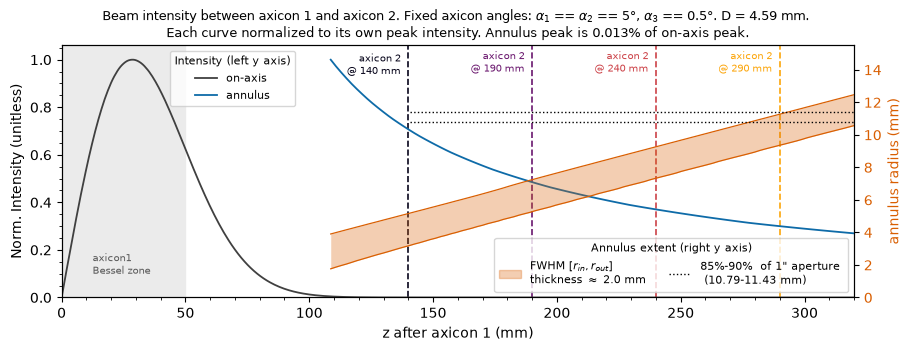

In [511]:
# --- figure 1: leg 1 (axicon 1 -> axicon 2) ---------------------------------
fig, ax1 = plt.subplots(figsize=(9, 3.4), layout="constrained")
ax1.plot(z1 * 1e3, I1 / np.nanmax(I1), color="0.25", lw=1.3,
         label="on-axis", zorder=3)
ax1.plot(z1r * 1e3, I_rg / I_rg.max(), color="#0e6ba8", lw=1.3,
         label="annulus", zorder=3)
ax1.axvspan(ax1_bessel_zone[0] * 1e3, ax1_bessel_zone[1] * 1e3, color="0.92", zorder=1)
ax1.annotate(f"axicon1 \nBessel zone",
             xy=[ax1_bessel_zone[0] * 1e3 + (ax1_bessel_zone[1] - ax1_bessel_zone[0]) * 1e3 / 4, 0.1], fontsize=7.5, color="0.35")

Y_TXT_ACHORS = (0.94, 0.95, 0.95, 0.95)      # staggered heights for the L12 labels
for run, c, ytxt in zip(runs_l12, sweep_colors(len(runs_l12)),
                        Y_TXT_ACHORS):
    ax1.axvline(run["L12"], color=c, lw=1.2, ls="--")
    last = run is runs_l12[-1]      # @300 sits next to the z_90 line: go left
    ax1.annotate(f"axicon 2\n@ {run['L12']:g} mm",
                 xy=(run["L12"] - 3, ytxt),
                 ha="right", fontsize=7.5, color=c)
# 90%-aperture limit on PLACING axicon 2 (1" optic) in the growing annulus
# ax1.axvline(z_90 * 1e3, color="tab:red", lw=1.1, ls="-.")
# ax1.annotate(f"annulus $r_{{out}}$ > {F_AP:.0%} of 1\" aperture\n"
#              f"beyond z ≈ {z_90 * 1e3:.0f} mm",
#              xy=(z_90 * 1e3, 0.97), xytext=(z_90 * 1e3 - 8, 0.80),
#              ha="left", fontsize=8, color="tab:red",
#              arrowprops=dict(arrowstyle="->", color="tab:red", lw=0.8))
ax1.set_xlim(0, Z1_MAX * 1e3)
ax1.set_ylim(0, 1.06)
ax1.set_xlabel("z after axicon 1 (mm)")
ax1.set_ylabel("Norm. Intensity (unitless)")
ax1.minorticks_on()
ax1.legend(fontsize=8, loc="upper left", bbox_to_anchor=(0.13, 1.0), title="Intensity (left y axis)", title_fontsize=8)
ax1.set_title(f"Beam intensity between axicon 1 and axicon 2. "
    f"Fixed axicon angles: $\\alpha_{{1}}$ == $\\alpha_{{2}}$ == {CANDIDATE_1['Axicon1_deg']:g}$\\degree$, $\\alpha_{{3}}$ == {CANDIDATE_1['Axicon3_deg']:g}$\\degree$. D = {CANDIDATE_1['GaussianBeamWaist_mm']:g} mm. \n"
    f"Each curve normalized to its own peak intensity. Annulus peak is {(I_rg.max() / I1.max())*100:.2g}% of on-axis peak.", 
    fontsize=9)

# right axis: annulus FWHM extent [r_in, r_out] — the band HEIGHT is the
# ring thickness (~constant); the dotted level is the 90% aperture radius
ax1r = ax1.twinx()
ax1r.fill_between(z1r * 1e3, rin1 / mm, rout1 / mm, color="#d95f02",
                  alpha=0.30, lw=0)
ax1r.plot(z1r * 1e3, rout1 / mm, color="#d95f02", lw=0.9)
ax1r.plot(z1r * 1e3, rin1 / mm, color="#d95f02", lw=0.9)
ax1r.axhline(F_AP[0] * R_AP, xmin=0.44, xmax=1, color="black", lw=1, ls=":")
ax1r.axhline(F_AP[1] * R_AP, xmin=0.44, xmax=1, color="black", lw=1, ls=":")
ax1r.set_ylim(0, 15.5)
ax1r.set_ylabel("annulus radius (mm)", color="#d95f02")
ax1r.tick_params(axis="y", labelcolor="#d95f02")
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
ax1r.legend(handles=[
    Patch(facecolor="#d95f02", alpha=0.30, edgecolor="#d95f02",
          label=(f"FWHM $[r_{{in}}, r_{{out}}]$\n"
                 f"thickness $\\approx$ {np.mean(rout1 - rin1) / mm:.1f} mm")),
    Line2D([], [], color="black", lw=1, ls=":",
           label=f"{F_AP[0]:.0%}-{F_AP[1]:.0%}  of 1\" aperture \n ({F_AP[0] * R_AP:.2f}-{F_AP[1] * R_AP:.2f} mm)")],
    fontsize=8, loc="lower right", ncols=2, title="Annulus extent (right y axis)", title_fontsize=8)
# ax1r.grid(which="major", color="0.9", lw=0.6, ls="-", zorder=10)
save_fig("theory_three_axicon_L12_between_axicon12")
plt.show()

saved images/final_report_theory_2026_08_12/theory_three_axicon_L12.png


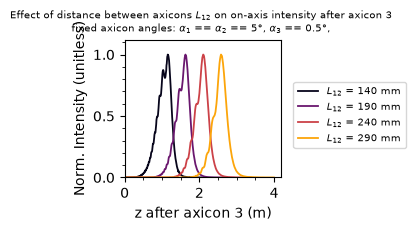

In [520]:
# --- figure 2: on-axis intensity after axicon 3 per L12 ---------------------
fig, ax = plt.subplots(figsize=(3.375, 2.2), layout="constrained")

th3 = runs_l12[0]["th3"]
for run, c in zip(runs_l12, sweep_colors(len(runs_l12))):
    z_zone = ring_radius_mm(dict(CANDIDATE_1, L12_mm=run["L12"])) * mm / th3
    m_ = np.isfinite(run["onax"]) & (run["z3"] > 0.5 * z_zone)
    pk = run["onax"][m_].max()
    # ax.plot(run["z3"], run["onax"] / pk, color=c, lw=1.3,
    #         label=(f"$L_{{12}}$ = {run['L12']:g} mm:  annulus FWHM "
    #                f"[{(run['R_a'] - run['Delta'] / 2) / mm:.1f}, "
    #                f"{(run['R_a'] + run['Delta'] / 2) / mm:.1f}] mm"))
    ax.plot(run["z3"], run["onax"] / pk, color=c, lw=1.3,
            label=(f"$L_{{12}}$ = {run['L12']:g} mm"))
# aperture limit: zone center z = R_a/theta3 needs R_a <= 0.9 R_ap
z_ap = F_AP[1] * R_AP * mm / th3
ax.set_xlabel("z after axicon 3 (m)")
ax.set_ylabel("Norm. Intensity (unitless)")
ax.set_xlim(0, None)
ax.set_ylim(0, 1.12)
ax.minorticks_on()
fig.legend(fontsize=7.5, loc="outside center right")
ax.set_title(f"Effect of distance between axicons $L_{{12}}$ on on-axis intensity after axicon 3 \n"
             f"fixed axicon angles: $\\alpha_{{1}}$ == $\\alpha_{{2}}$ == {CANDIDATE_1['Axicon1_deg']:g}$\\degree$, $\\alpha_{{3}}$ == {CANDIDATE_1['Axicon3_deg']:g}$\\degree$, ",
             fontsize=7.5)
save_fig("theory_three_axicon_L12")
plt.show()

saved images/final_report_theory_2026_08_12/theory_three_axicon_L12_annuli.png


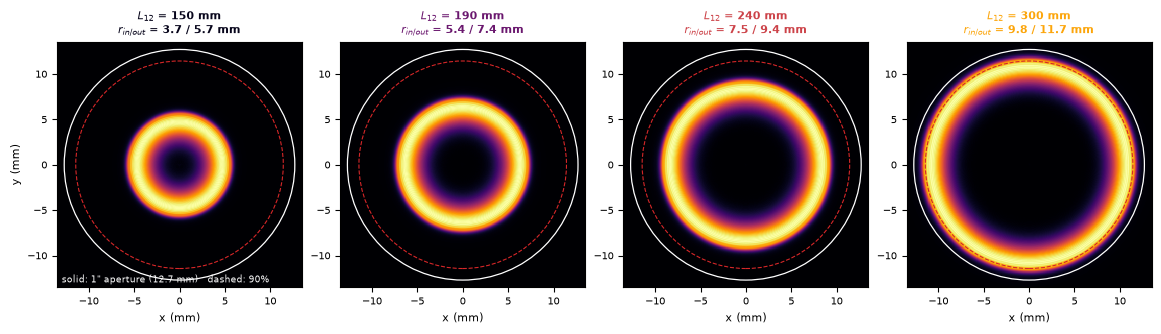

In [ ]:
# --- figure 3: the annulus at the axicon-3 plane per L12 --------------------
fig, axs = plt.subplots(1, len(runs_l12), figsize=(11.5, 3.5),
                        layout="constrained")
R_VIEW_MM = 13.5
for col, (run, c) in enumerate(zip(runs_l12, sweep_colors(len(runs_l12)))):
    axi = axs[col]
    In = run["I_ring"] / run["I_ring"].max()
    g = np.linspace(-R_VIEW_MM, R_VIEW_MM, 480)
    XX, YY = np.meshgrid(g, g)
    img = np.interp(np.hypot(XX, YY), run["r"] / mm, In, right=0.0)
    axi.imshow(np.sqrt(img), cmap="inferno", vmin=0, vmax=1, origin="lower",
               interpolation="nearest", extent=[-R_VIEW_MM, R_VIEW_MM] * 2)
    axi.add_patch(plt.Circle((0, 0), R_AP, fill=False, color="w", lw=0.9))
    axi.add_patch(plt.Circle((0, 0), F_AP * R_AP, fill=False, color="tab:red",
                             ls="--", lw=0.8))
    axi.set_title(f"$L_{{12}}$ = {run['L12']:g} mm\n"
                  f"$r_{{in/out}}$ = {(run['R_a'] - run['Delta'] / 2) / mm:.1f}"
                  f" / {(run['R_a'] + run['Delta'] / 2) / mm:.1f} mm",
                  fontsize=8, color=c, fontweight="bold")
    axi.set_xlabel("x (mm)", fontsize=8)
    if col == 0:
        axi.set_ylabel("y (mm)", fontsize=8)
    axi.tick_params(labelsize=7)
    axi.set_box_aspect(1)
axs[0].annotate("solid: 1\" aperture (12.7 mm)   dashed: 90%",
                           xy=(0.02, 0.02), xycoords="axes fraction",
                           fontsize=6.5, color="w")
save_fig("theory_three_axicon_L12_annuli")
plt.show()

NOTE a12=1: outside the model's valid range (needs L12 > 1.2 zmax and a resolved fringe) — skipped
saved images/final_report_theory_2026_08_12/theory_three_axicon_a12.png


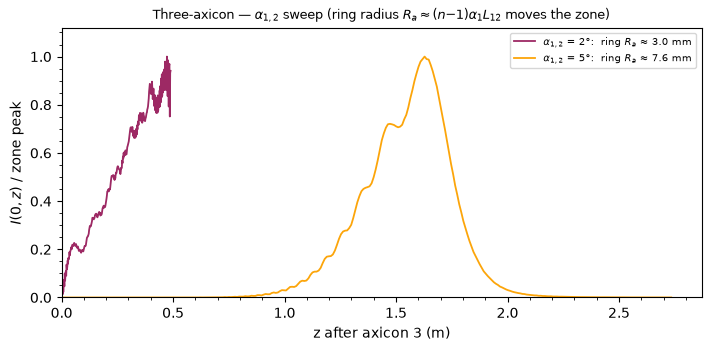

In [ ]:
# --- sweep 4: axicon 1/2 angle -----------------------------------------------
fig, ax = plt.subplots(figsize=(7, 3.4), layout="constrained")
# sweep limits: below ~2 deg the cones still overlap at axicon 2 (no clean
# annulus, L12 < 1.2 zmax — the simulator asserts) and the small ring makes
# a short, messy zone; above ~6 deg the N=4096 radial grid no longer
# resolves the axicon fringes (asserts too).
sweep_three_axicon("a12", (1.0, 2.0, 5.0), ax,
    lambda v, o: (f"$\\alpha_{{1,2}}$ = {v:g}°:  ring $R_a$ ≈ "
                  f"{ring_radius_mm(o):.1f} mm"))
ax.set_title("Three-axicon — $\\alpha_{1,2}$ sweep (ring radius "
             "$R_a \\approx (n{-}1)\\alpha_1 L_{12}$ moves the zone)",
             fontsize=9)
save_fig("theory_three_axicon_a12")
plt.show()


saved images/final_report_theory_2026_08_12/theory_three_axicon_a3.png


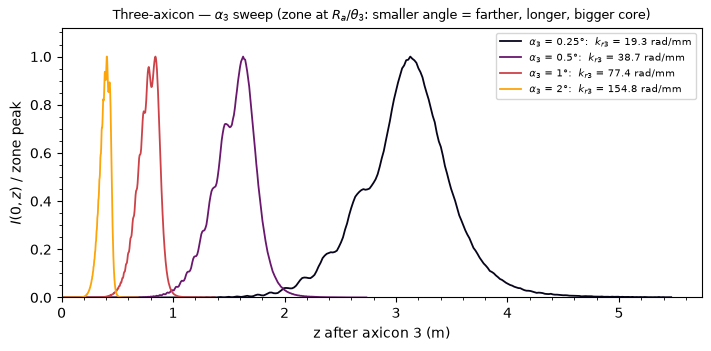

In [ ]:
# --- sweep 5: axicon 3 angle -------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 3.4), layout="constrained")
sweep_three_axicon("a3", (0.25, 0.5, 1.0, 2.0), ax,
    lambda v, o: (f"$\\alpha_3$ = {v:g}°:  $k_{{r3}}$ = "
                  f"{axicon_kr(v, n=N_UV_FUSED_SILICA, k=K0) / 1e3:.1f} rad/mm"))
ax.set_title("Three-axicon — $\\alpha_3$ sweep (zone at $R_a/\\theta_3$: "
             "smaller angle = farther, longer, bigger core)", fontsize=9)
save_fig("theory_three_axicon_a3")
plt.show()


saved images/final_report_theory_2026_08_12/theory_three_axicon_D.png


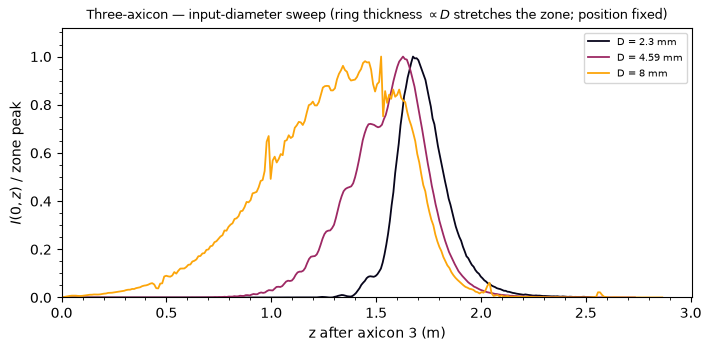

In [ ]:
# --- sweep 6: input beam diameter --------------------------------------------
fig, ax = plt.subplots(figsize=(7, 3.4), layout="constrained")
# D=9.44 mm (the candidate-#2 beam) breaks the model at THIS baseline: with
# L23 = 50 mm the beam cones barely separate before axicon 2 (zmax = 118 mm
# vs L12 = 190) and the z-grid heuristic collapses. It worked for candidate
# #2 because that geometry used L12 = 240 / L23 = 220. Sweep to 8 mm here.
sweep_three_axicon("D", (2.3, 4.59, 8.0), ax,
    lambda v, o: f"D = {v:g} mm")
ax.set_title("Three-axicon — input-diameter sweep (ring thickness "
             "$\\propto D$ stretches the zone; position fixed)", fontsize=9)
save_fig("theory_three_axicon_D")
plt.show()
